# SmartHandover — Day 3: Audio Pipeline (SpeechBrain + Whisper)

**Part A:** Classificacao de emocao a partir de audio com `superb/wav2vec2-large-superb-er` (IEMOCAP, 4 classes: ang/hap/sad/neu)

**Part B:** Transcricao audio->texto com Whisper (`openai/whisper-small`) + calculo de WER

**Gestao de VRAM:** SpeechBrain e descarregado antes de carregar o Whisper.

In [1]:
#%pip install torch torchaudio transformers datasets pandas scikit-learn tqdm matplotlib openai-whisper jiwer --quiet

In [2]:
# === CONFIG ===
USE_MOCK = False      # True = dados dummy (sem download), False = MELD real
DEVICE = None         # None = auto-detect, "cpu" ou "cuda"
SKIP_WHISPER = False  # True = saltar Part B (Whisper ASR)
WHISPER_SAMPLES = 50  # N amostras para teste de WER

In [3]:
import os, sys, time
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

if DEVICE is None:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

TARGET_LABELS = ["anger", "frustration", "sadness", "neutral", "satisfaction"]
TARGET_LABEL2ID = {label: i for i, label in enumerate(TARGET_LABELS)}

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


## 1. Carregar dados

In [4]:
def create_mock_data():
    rng = np.random.default_rng(42)
    labels = ["anger", "anger", "frustration", "frustration",
              "sadness", "sadness", "neutral", "neutral", "neutral",
              "satisfaction", "satisfaction"]
    texts = [
        "I am so angry at you right now!", "This is absolutely unacceptable!",
        "This is so frustrating, nothing works.", "I've been waiting for an hour.",
        "I feel so sad and lonely today.", "It breaks my heart to see this.",
        "The meeting is at 3pm.", "Sure, that works for me.", "Okay.",
        "This is wonderful, I'm so happy!", "Great job, I really appreciate your help!",
    ]
    rows = []
    for i, (text, label) in enumerate(zip(texts, labels)):
        audio_array = rng.standard_normal(16000 * 2).astype(np.float32) * 0.01
        rows.append({"audio_id": f"mock_{i:04d}", "text": text,
                     "target_emotion": label, "audio_array": audio_array, "sr": 16000})
    return pd.DataFrame(rows)


def load_meld_audio_dataframe():
    from src.data.load_meld import load_meld
    rows = []
    for split in ["train", "validation", "test"]:
        print(f"  Loading MELD split: {split} ...")
        ds = load_meld(split=split, streaming=False)
        for idx, example in enumerate(ds):
            rows.append({
                "audio_id": f"{split}_{idx:05d}", "text": example["text"],
                "target_emotion": example["target_emotion"],
                "audio_array": np.array(example["audio"]["array"], dtype=np.float32),
                "sr": example["audio"]["sampling_rate"],
            })
    return pd.DataFrame(rows)


if USE_MOCK:
    print("[INFO] A usar dados MOCK.")
    df = create_mock_data()
else:
    print("[INFO] A carregar MELD com audio (pode demorar)...")
    try:
        df = load_meld_audio_dataframe()
    except Exception as e:
        print(f"[WARN] Falha: {e}\n[WARN] Fallback para mock.")
        df = create_mock_data()

print(f"\nTotal amostras: {len(df)}")
df["target_emotion"].value_counts()

[INFO] A carregar MELD com audio (pode demorar)...
  Loading MELD split: train ...
  Loading MELD split: validation ...
  Loading MELD split: test ...

Total amostras: 12070


target_emotion
neutral         6434
satisfaction    2308
anger           1968
sadness         1002
frustration      358
Name: count, dtype: int64

## 2. Part A — SpeechBrain (Emocao por Audio)

Modelo: `superb/wav2vec2-large-superb-er` (IEMOCAP, 4 classes)

Mapeamento: ang->anger, hap->satisfaction, sad->sadness, neu->neutral

(SpeechBrain nao tem "frustration" — usamos anger como proxy no ensemble)

In [5]:
from src.classifiers.speechbrain_classifier import SpeechBrainClassifier, IEMOCAP_TO_TARGET

print(f"A carregar modelo SpeechBrain (device={DEVICE})...")
t0 = time.time()
sb = SpeechBrainClassifier(device=DEVICE)
print(f"Modelo carregado em {time.time() - t0:.1f}s")

sb_results = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="SpeechBrain"):
    res = sb.predict_and_classify(row["audio_array"], sr=row["sr"])
    sb_results.append({
        "audio_id": row["audio_id"],
        "text": row["text"],
        "true_label": row["target_emotion"],
        "predicted_class": res["predicted_class"],
        "sb_ang": res["ang"], "sb_hap": res["hap"],
        "sb_sad": res["sad"], "sb_neu": res["neu"],
    })

sb_df = pd.DataFrame(sb_results)
sb_df.head(10)

A carregar modelo SpeechBrain (device=cuda)...


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Modelo carregado em 3.0s


SpeechBrain:   0%|          | 0/12070 [00:00<?, ?it/s]

,audio_id,text,true_label,predicted_class,sb_ang,sb_hap,sb_sad,sb_neu
0,train_00000,also I was the point person on my companys tr...,neutral,neutral,0.034328,0.375352,0.002966,0.587355
1,train_00001,You mustve had your hands full.,neutral,neutral,0.003407,0.090515,0.001341,0.904737
2,train_00002,No dont I beg of you!,frustration,satisfaction,0.204185,0.538168,0.000810,0.256837
3,train_00003,"All right then, well have a definite answer f...",neutral,neutral,0.129340,0.392907,0.006741,0.471012
4,train_00004,Absolutely. You can relax,neutral,neutral,0.011744,0.286834,0.002312,0.699111
5,train_00005,That I did. That I did.,neutral,satisfaction,0.021168,0.860947,0.006738,0.111147
6,train_00006,So lets talk a little bit about your duties.,neutral,satisfaction,0.049886,0.598829,0.000973,0.350313
7,train_00007,"Now youll be heading a whole division, so you...",neutral,neutral,0.040904,0.265053,0.032953,0.661090
8,train_00008,I see.,neutral,neutral,0.036656,0.243518,0.001292,0.718534
9,train_00009,But therell be perhaps 30 people under you so...,neutral,neutral,0.039479,0.409693,0.004541,0.546287


In [6]:
# Libertar VRAM
del sb
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("SpeechBrain descarregado, VRAM libertada.")

SpeechBrain descarregado, VRAM libertada.


## 3. Guardar CSV SpeechBrain

In [7]:
sb_path = os.path.join("..", "data", "processed", "speechbrain_predictions.csv")
os.makedirs(os.path.dirname(sb_path), exist_ok=True)
sb_df.to_csv(sb_path, index=False)
print(f"Guardado em: {sb_path}")

Guardado em: ..\data\processed\speechbrain_predictions.csv


## 4. Metricas SpeechBrain

In [8]:
from src.evaluation.metrics import compute_metrics, print_metrics

SB_TARGET_MAP = {"anger": 0, "satisfaction": 4, "sadness": 2, "neutral": 3}

y_true = [TARGET_LABEL2ID[l] for l in sb_df["true_label"]]
y_pred = [SB_TARGET_MAP[l] for l in sb_df["predicted_class"]]

sb_metrics = compute_metrics(y_true, y_pred, target_names=TARGET_LABELS)
print_metrics(sb_metrics)


  Accuracy     : 0.3983
  Weighted F1  : 0.3994
  Macro F1     : 0.2581
  Frustration R: 0.0000  << KEY METRIC

  Class             Prec    Rec     F1  Support
  -------------------------------------------
  anger            0.375  0.361  0.368     1968
  frustration      0.000  0.000  0.000      358 <<
  sadness          0.235  0.042  0.071     1002
  neutral          0.667  0.399  0.499     6434
  satisfaction     0.242  0.645  0.352     2308

  Confusion Matrix (rows=true, cols=pred):
            anger  frust  sadne  neutr  satis
    anger     711      0     18    382    857
    frust      81      0      4    103    170
    sadne     135      0     42    253    572
    neutr     720      0     84   2566   3064
    satis     247      0     31    541   1489


## 5. Part B — Whisper ASR + WER

Transcricao audio->texto com `openai/whisper-small` numa amostra de 50 exemplos.

Calcula Word Error Rate (WER) vs texto original do MELD.

**Nota:** Se o WER > 15%, usamos o texto original do MELD para o ensemble (nao o transcrito).

In [9]:
if not SKIP_WHISPER:
    from src.classifiers.whisper_asr import WhisperASR
    from jiwer import wer as compute_wer

    subset = df.head(WHISPER_SAMPLES).copy()

    print(f"A carregar Whisper (device={DEVICE})...")
    t0 = time.time()
    asr = WhisperASR(model_size="small", device=DEVICE)
    print(f"Modelo carregado em {time.time() - t0:.1f}s")

    references, hypotheses = [], []
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Whisper ASR"):
        transcription = asr.transcribe(row["audio_array"], sr=row["sr"])
        references.append(row["text"])
        hypotheses.append(transcription)

    # Libertar VRAM
    del asr
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    overall_wer = compute_wer(references, hypotheses)
    print(f"\nWER: {overall_wer:.4f} ({overall_wer*100:.1f}%)")
    print(f"Target < 15%: {'PASS' if overall_wer < 0.15 else 'FAIL'}")
else:
    print("[INFO] Whisper ASR saltado (SKIP_WHISPER = True).")

A carregar Whisper (device=cuda)...
Modelo carregado em 3.6s


Whisper ASR:   0%|          | 0/50 [00:00<?, ?it/s]


WER: 0.3684 (36.8%)
Target < 15%: FAIL


In [10]:
if not SKIP_WHISPER:
    print("Exemplos de transcricao:\n")
    for i in range(min(8, len(references))):
        ref = references[i][:90].encode("ascii", errors="replace").decode()
        hyp = hypotheses[i][:90].encode("ascii", errors="replace").decode()
        print(f"  [{i}] REF: {ref}")
        print(f"       HYP: {hyp}\n")

Exemplos de transcricao:

  [0] REF: also I was the point person on my company?s transition from the KL-5 to GR-6 system.
       HYP: Also, I was the point person on my company's transition from the KL5 to GR6 systems.

  [1] REF: You must?ve had your hands full.
       HYP: You must have had your hands full.

  [2] REF: No don?t I beg of you!
       HYP: No, John, I beg of you.

  [3] REF: All right then, we?ll have a definite answer for you on Monday, but I think I can say with
       HYP: All right then. We'll have a definite answer for you on Monday. But I think I can say with

  [4] REF: Absolutely.  You can relax
       HYP: You can relax. You did great. Yeah, I got it safe.

  [5] REF: That I did. That I did.
       HYP: That I did. That I did.

  [6] REF: So let?s talk a little bit about your duties.
       HYP: So let's talk a little bit about your duties.

  [7] REF: Now you?ll be heading a whole division, so you?ll have a lot of duties.
       HYP: You'll be heading a whole 

## 6. Comparacao com baselines (Days 1-2)

In [11]:
import matplotlib.pyplot as plt

rows = [("SpeechBrain (audio)", sb_metrics["weighted_f1"], sb_metrics["macro_f1"],
         sb_metrics["frustration_recall"])]

for name, path in [("VADER", "../data/processed/vader_predictions.csv"),
                    ("GoEmotions", "../data/processed/goemo_predictions.csv")]:
    if os.path.exists(path):
        prev = pd.read_csv(path)
        yt = [TARGET_LABEL2ID[l] for l in prev["true_label"]]
        yp = [TARGET_LABEL2ID[l] for l in prev["predicted_class"]]
        m = compute_metrics(yt, yp, target_names=TARGET_LABELS)
        rows.append((name, m["weighted_f1"], m["macro_f1"], m["frustration_recall"]))

comparison = pd.DataFrame(rows, columns=["Model", "W-F1", "M-F1", "Frust Recall"])
comparison = comparison.sort_values("W-F1", ascending=False).reset_index(drop=True)
comparison.style.format({"W-F1": "{:.4f}", "M-F1": "{:.4f}", "Frust Recall": "{:.4f}"})

,Model,W-F1,M-F1,Frust Recall
0,GoEmotions,0.5596,0.4049,0.4274
1,VADER,0.4795,0.2962,0.0000
2,SpeechBrain (audio),0.3994,0.2581,0.0000


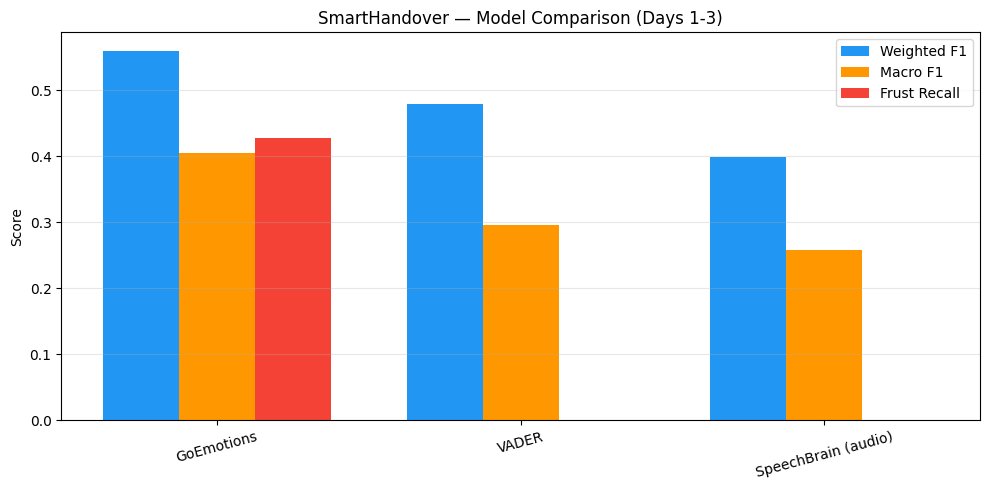

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison))
width = 0.25

ax.bar([i - width for i in x], comparison["W-F1"], width, label="Weighted F1", color="#2196F3")
ax.bar(x, comparison["M-F1"], width, label="Macro F1", color="#FF9800")
ax.bar([i + width for i in x], comparison["Frust Recall"], width, label="Frust Recall", color="#F44336")

ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=15)
ax.set_ylabel("Score")
ax.set_title("SmartHandover — Model Comparison (Days 1-3)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()